In [8]:
#CELL1 环境与配置
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import time
import random
import os
%matplotlib inline

#1.硬件与环境check
def check_environment():
    print(f"PyTorch 版本: {torch.__version__}")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"实验运行设备: {device}")
    return device

#2.设置随机种子
def set_seed(seed = 42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    #这里我的设备没有cuda可用，为了结构完整便于复现设置了一下
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

DEVICE = check_environment()
set_seed(42)

#3.实验矩阵全局配置（参考README）
CONFIG = {
    "batch_size" : 128,
    "base_lr": 0.001,
    "device": DEVICE,
    #定义的八组实验
    "experiment_matrix":[
        # Group 1: 固定学习率
        {"id": "G1-Exp1", "model_type": "MLP",       "aug": False, "scheduler": False, "epochs": 10},
        {"id": "G1-Exp2", "model_type": "LeNet5",    "aug": False, "scheduler": False, "epochs": 15},
        {"id": "G1-Exp3", "model_type": "StrongCNN", "aug": False, "scheduler": False, "epochs": 15},
        {"id": "G1-Exp4", "model_type": "StrongCNN", "aug": True,  "scheduler": False, "epochs": 15},
        
        # Group 2: 动态调整学习率（StepLR)
        {"id": "G2-Exp5", "model_type": "MLP",       "aug": False, "scheduler": True,  "epochs": 10},
        {"id": "G2-Exp6", "model_type": "LeNet5",    "aug": False, "scheduler": True,  "epochs": 15},
        {"id": "G2-Exp7", "model_type": "StrongCNN", "aug": False, "scheduler": True,  "epochs": 15},
        {"id": "G2-Exp8", "model_type": "StrongCNN", "aug": True,  "scheduler": True,  "epochs": 15},
    ]
}
print(f"\n实验矩阵已就绪,共计 {len(CONFIG['experiment_matrix'])} 组实验。")

PyTorch 版本: 2.10.0+cpu
实验运行设备: cpu

实验矩阵已就绪,共计 8 组实验。


100.0%
100.0%
100.0%
100.0%
d:\Dev_w\Courses\AI_Guide_Tongji\MNIST_three_method\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Dev_w\Courses\AI_Guide_Tongji\MNIST_three_method\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25454 (\N{CJK UNIFIED IDEOGRAPH-636E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Dev_w\Courses\AI_Guide_Tongji\MNIST_three_method\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22686 (\N{CJK UNIFIED IDEOGRAPH-589E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Dev_w\Courses\AI_Guide_Tongji\MNIST_three_method\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24378 (\N{CJK UNIFIED IDEOGRAPH-5F3A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\D

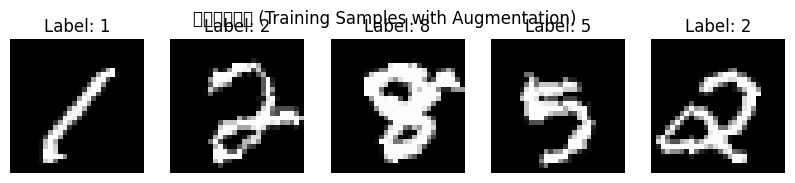

In [ ]:
#CELL2 数据加载与流水线
def get_dataloader(use_augmentation=False,batch_size = 128):
    """
    根据配置获取训练集和测试集的迭代器。
    参数:
        use_augmentation: 是否开启数据增强
        batch_size: 批处理大小
    """
    #1.定义基础张量化与标准化步骤
    # MNIST 的官方均值为 0.1307，标准差为 0.3081
    base_transforms = [
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ]

    #2.数据增强的训练集变换，如果开启增强，则在基础步骤前插入随机变换
    if use_augmentation:
        #增加旋转(±15°)和平移(10%)
        #注意：数据增强的操作必须放在ToTensor之前，语义更清晰
        train_transform = transforms.Compose([
            transforms.RandomRotation(15),
            transforms.RandomAffine(degrees=0,translate=(0.1,0.1)),
            *base_transforms
        ])
    else:
        train_transform = transforms.Compose(base_transforms)

    #3.测试集变换，不加增强
    test_transform = transforms.Compose(base_transforms)

    #4.加载数据集，下载到./data目录，transform=是注册一个预处理规则，但还没执行
    train_set = torchvision.datasets.MNIST(
        root='./data', train=True, download=True, transform=train_transform
    )
    test_set = torchvision.datasets.MNIST(
        root='./data', train=False, download=True, transform=test_transform
    )

    #5.创建DataLoader，shuffle是打乱，num_workers=0是不用额外主进程加载数据
    # pin_memory=True 在有 GPU 时可以加速，只有 CPU 时设为 False 即可
    train_loader = DataLoader(
        train_set, batch_size=batch_size, shuffle=True, num_workers=0
    )
    test_loader = DataLoader(
        test_set, batch_size=1000, shuffle=False, num_workers=0
    )

    return train_loader, test_loader

#数据可视化验证
temp_loader, _ = get_dataloader(use_augmentation=True)
images, labels = next(iter(temp_loader))

plt.figure(figsize=(10, 2))
plt.suptitle("数据增强示例 (Training Samples with Augmentation)")
for i in range(5):
    plt.subplot(1, 5, i+1)
    # 还原归一化以便显示
    img = images[i].numpy().squeeze()
    plt.imshow(img, cmap='gray')
    plt.title(f"Label: {labels[i]}")
    plt.axis('off')
plt.show()